# NDBC Buoy Wind Versus HRRR F00 Surface Wind

Download NOAA/NDBC realtime buoy observations near one UTC valid time, download HRRR forecast-hour-zero 10 m wind for the same time, and compare buoy wind speed and direction with the nearest HRRR water grid point.

In [1]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from datetime import datetime, timedelta, timezone
from io import StringIO
from pathlib import Path
import os
import xml.etree.ElementTree as ET

repo_tmp = Path("tmp").resolve()
data_dir = Path("data").resolve()
(repo_tmp / "matplotlib").mkdir(parents=True, exist_ok=True)
(repo_tmp / "herbie-config").mkdir(parents=True, exist_ok=True)
(repo_tmp / "cache").mkdir(parents=True, exist_ok=True)
data_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(repo_tmp / "matplotlib"))
os.environ.setdefault("HERBIE_CONFIG_PATH", str(repo_tmp / "herbie-config"))
os.environ.setdefault("XDG_CACHE_HOME", str(repo_tmp / "cache"))

import numpy as np
import pandas as pd
import requests
import xarray as xr
from herbie import Herbie
from scipy.spatial import cKDTree

from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# Same valid time as the satellite, radar, and surface-station notebooks.
valid_time_utc = datetime(2026, 6, 2, 18, 0, tzinfo=timezone.utc)

# NDBC realtime text files usually include recent data. This default date is close to
# the notebook creation date; for older cases, swap in NDBC historical stdmet files.
obs_window_minutes = 30
ndbc_active_stations_url = "https://www.ndbc.noaa.gov/activestations.xml"
ndbc_realtime_url_template = "https://www.ndbc.noaa.gov/data/realtime2/{station_id}.txt"

# CONUS plus adjacent coastal waters and Great Lakes: west, east, south, north.
map_extent = [-125.0, -66.5, 24.0, 50.0]

# Plotting/downloading controls.
station_request_workers = 8
hrrr_plot_stride = 6
minimum_station_count = 10
error_color_limit_mps = 6.0

## NDBC Buoy Observations

The active-station XML gives station IDs and locations. Each station's realtime text file is whitespace-delimited, with wind direction in degrees true and wind speed in m/s.

In [3]:
def fetch_text_with_cache(url, cache_path, timeout=60):
    """Fetch text once and reuse a local cache on reruns."""
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if cache_path.exists() and cache_path.stat().st_size > 0:
        return cache_path.read_text()

    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    cache_path.write_text(response.text)
    return response.text


def list_ndbc_buoy_stations(url=ndbc_active_stations_url, extent=map_extent):
    """Return active NDBC buoy stations with meteorological data inside the map extent."""
    text = fetch_text_with_cache(url, data_dir / "ndbc" / "activestations.xml")
    root = ET.fromstring(text)
    west, east, south, north = extent
    stations = []

    for node in root.findall("station"):
        attrs = node.attrib
        try:
            lat = float(attrs["lat"])
            lon = float(attrs["lon"])
        except (KeyError, TypeError, ValueError):
            continue

        if not (west <= lon <= east and south <= lat <= north):
            continue
        if attrs.get("type", "").lower() != "buoy":
            continue
        if attrs.get("met", "").lower() != "y":
            continue

        stations.append(
            {
                "station_id": attrs.get("id"),
                "station_name": attrs.get("name", ""),
                "owner": attrs.get("owner", ""),
                "lat": lat,
                "lon": lon,
            }
        )

    return pd.DataFrame(stations).sort_values("station_id").reset_index(drop=True)


def parse_ndbc_realtime_text(station_id, text):
    """Parse one NDBC realtime standard-meteorological text response."""
    if not text.strip() or "No data" in text[:200]:
        return pd.DataFrame()

    df = pd.read_csv(
        StringIO(text),
        sep=r"\s+",
        skiprows=[1],
        na_values=["MM"],
    ).rename(columns={"#YY": "YY"})

    required = {"YY", "MM", "DD", "hh", "mm", "WDIR", "WSPD"}
    if not required.issubset(df.columns):
        return pd.DataFrame()

    numeric_columns = ["YY", "MM", "DD", "hh", "mm", "WDIR", "WSPD", "GST"]
    for column in numeric_columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")

    df["time"] = pd.to_datetime(
        {
            "year": df["YY"],
            "month": df["MM"],
            "day": df["DD"],
            "hour": df["hh"],
            "minute": df["mm"],
        },
        utc=True,
        errors="coerce",
    )
    df["station_id"] = station_id
    return df


def nearest_station_observation(station, valid_time, window_minutes=obs_window_minutes):
    """Fetch one station and keep its nearest usable wind report to valid_time."""
    station_id = station["station_id"]
    date_key = pd.Timestamp(valid_time).strftime("%Y%m%d")
    cache_path = data_dir / "ndbc" / "realtime2" / f"{station_id}_{date_key}.txt"
    url = ndbc_realtime_url_template.format(station_id=station_id)

    try:
        text = fetch_text_with_cache(url, cache_path, timeout=45)
        df = parse_ndbc_realtime_text(station_id, text)
    except Exception as exc:
        return None, f"{station_id}: {type(exc).__name__}"

    if df.empty:
        return None, f"{station_id}: no parseable realtime rows"

    target = pd.Timestamp(valid_time).tz_convert("UTC")
    window_start = target - pd.Timedelta(minutes=window_minutes)
    window_end = target + pd.Timedelta(minutes=window_minutes)
    window = df.loc[df["time"].between(window_start, window_end)].copy()
    window = window[np.isfinite(window["WSPD"]) & np.isfinite(window["WDIR"])]
    window = window[(window["WSPD"] >= 0.0) & window["WDIR"].between(0.0, 360.0)]
    if window.empty:
        return None, f"{station_id}: no wind reports in window"

    window["minutes_from_valid"] = (window["time"] - target).abs() / pd.Timedelta(minutes=1)
    row = window.sort_values("minutes_from_valid").iloc[0].to_dict()
    row.update(station)
    return row, None


def download_ndbc_buoy_observations(valid_time, stations):
    """Fetch buoy winds in parallel and return one nearest report per station."""
    rows = []
    failures = []
    station_records = stations.to_dict("records")

    with ThreadPoolExecutor(max_workers=station_request_workers) as executor:
        futures = {
            executor.submit(nearest_station_observation, station, valid_time): station["station_id"]
            for station in station_records
        }
        for index, future in enumerate(as_completed(futures), start=1):
            row, failure = future.result()
            if row is not None:
                rows.append(row)
            elif failure:
                failures.append(failure)
            if index % 25 == 0 or index == len(futures):
                print(f"Checked {index}/{len(futures)} station files; usable reports: {len(rows)}")

    obs = pd.DataFrame(rows)
    if obs.empty:
        raise ValueError(
            f"No usable NDBC buoy wind reports within +/-{obs_window_minutes} minutes of "
            f"{pd.Timestamp(valid_time):%Y-%m-%d %H:%M UTC}."
        )

    obs = obs.rename(
        columns={
            "WDIR": "observed_wind_direction_deg",
            "WSPD": "observed_wind_speed_mps",
            "GST": "observed_gust_mps",
        }
    )
    keep_columns = [
        "station_id",
        "station_name",
        "owner",
        "lat",
        "lon",
        "time",
        "minutes_from_valid",
        "observed_wind_direction_deg",
        "observed_wind_speed_mps",
        "observed_gust_mps",
    ]
    keep_columns = [column for column in keep_columns if column in obs.columns]
    return obs[keep_columns].sort_values("station_id").reset_index(drop=True), failures


stations = list_ndbc_buoy_stations()
print(f"Active meteorological buoy stations in extent: {len(stations)}")

obs, station_failures = download_ndbc_buoy_observations(valid_time_utc, stations)
if len(obs) < minimum_station_count:
    raise ValueError(f"Only {len(obs)} usable buoy wind reports found; expected at least {minimum_station_count}.")

print(f"Usable buoy wind observations: {len(obs)}")
print(f"Skipped station files: {len(station_failures)}")
display(obs.head(10))

Active meteorological buoy stations in extent: 204


Checked 25/204 station files; usable reports: 20


Checked 50/204 station files; usable reports: 34


Checked 75/204 station files; usable reports: 50


Checked 100/204 station files; usable reports: 59


...

Checked 150/204 station files; usable reports: 92


Checked 175/204 station files; usable reports: 106


Checked 200/204 station files; usable reports: 106


Checked 204/204 station files; usable reports: 106
Usable buoy wind observations: 106
Skipped station files: 98


,station_id,station_name,owner,lat,lon,time,minutes_from_valid,observed_wind_direction_deg,observed_wind_speed_mps,observed_gust_mps
0,41001,EAST HATTERAS - 150 NM East of Cape Hatteras,NDBC,34.791,-72.420,2026-06-02 18:00:00+00:00,0.0,140.0,7.0,8.0
1,41002,SOUTH HATTERAS - 225 NM South of Cape Hatteras,NDBC,31.743,-74.955,2026-06-02 18:00:00+00:00,0.0,10.0,6.0,8.0
2,41004,"EDISTO - 41 NM Southeast of Charleston, SC",NDBC,32.502,-79.099,2026-06-02 18:00:00+00:00,0.0,40.0,12.0,15.0
3,41008,"GRAYS REEF - 40 NM Southeast of Savannah, GA",NDBC,31.400,-80.866,2026-06-02 18:00:00+00:00,0.0,40.0,10.0,12.0
4,41009,"CANAVERAL 20 NM East of Cape Canaveral, FL",NDBC,28.508,-80.185,2026-06-02 18:00:00+00:00,0.0,340.0,1.0,2.0
5,41010,CANAVERAL EAST - 120NM East of Cape Canaveral,NDBC,28.860,-78.478,2026-06-02 18:00:00+00:00,0.0,300.0,4.0,5.0
6,41013,"Frying Pan Shoals, NC",NDBC,33.441,-77.764,2026-06-02 18:00:00+00:00,0.0,30.0,11.0,14.0
7,41024,"Sunset Nearshore, NC (SUN2)",CORMP,33.837,-78.477,2026-06-02 18:08:00+00:00,8.0,30.0,4.0,6.0
8,41025,"Diamond Shoals, NC",NDBC,35.026,-75.380,2026-06-02 18:00:00+00:00,0.0,360.0,16.0,20.0
9,41029,"Capers Nearshore, SC (CAP2)",CORMP,32.803,-79.624,2026-06-02 18:08:00+00:00,8.0,60.0,11.0,15.0


## HRRR F00 Wind

HRRR `fxx=0` is valid at the model run time. The notebook downloads 10 m U/V wind and the surface land-sea mask, then masks the map background to water points.

In [4]:
def to_lon180(lon):
    """Convert longitude values from 0..360 to -180..180 when needed."""
    return ((np.asarray(lon) + 180.0) % 360.0) - 180.0


def wind_speed(u, v):
    """Wind speed from eastward/northward wind components."""
    return np.hypot(u, v)


def wind_direction_from_uv(u, v):
    """Meteorological wind direction in degrees true from U/V components."""
    return (np.degrees(np.arctan2(-u, -v)) + 360.0) % 360.0


def wind_components_from_speed_dir(speed, direction_deg):
    """Convert meteorological speed/direction to eastward/northward components."""
    radians = np.deg2rad(direction_deg)
    u = -speed * np.sin(radians)
    v = -speed * np.cos(radians)
    return u, v


def download_hrrr_10m_wind(valid_time):
    """Download HRRR f00 10 m wind and land-sea mask."""
    run_time = pd.Timestamp(valid_time).tz_convert("UTC").tz_localize(None).to_pydatetime()
    hrrr = Herbie(run_time, model="hrrr", product="sfc", fxx=0, save_dir=data_dir)
    subset_path = hrrr.download(
        ":(?:UGRD|VGRD):10 m above ground:|:LAND:surface:",
        verbose=False,
    )
    if isinstance(subset_path, (list, tuple)):
        subset_path = subset_path[0]

    ds = xr.open_dataset(
        subset_path,
        engine="cfgrib",
        backend_kwargs={"indexpath": ""},
    )
    expected = {"u10", "v10", "lsm"}
    missing = expected.difference(ds.data_vars)
    if missing:
        raise KeyError(f"Expected HRRR variables {sorted(expected)}, found {list(ds.data_vars)}")

    u10 = ds["u10"].squeeze().load()
    v10 = ds["v10"].squeeze().load()
    land_sea_mask = ds["lsm"].squeeze().load()
    latitude = ds["latitude"].load()
    longitude = (((ds["longitude"] + 180.0) % 360.0) - 180.0).load()
    ds.close()

    speed = xr.apply_ufunc(wind_speed, u10, v10)
    direction = xr.apply_ufunc(wind_direction_from_uv, u10, v10)
    water_mask = land_sea_mask < 0.5

    return xr.Dataset(
        data_vars={
            "u10_mps": u10,
            "v10_mps": v10,
            "wind_speed_mps": speed,
            "wind_direction_deg": direction,
            "water_mask": water_mask,
        },
        coords={"latitude": latitude, "longitude": longitude},
        attrs={
            "model": "HRRR",
            "product": "sfc",
            "forecast_hour": 0,
            "valid_time_utc": pd.Timestamp(valid_time).isoformat(),
            "grib_subset_path": str(subset_path),
        },
    )


hrrr_wind = download_hrrr_10m_wind(valid_time_utc)
print(f"HRRR subset: {Path(hrrr_wind.attrs['grib_subset_path']).name}")
print(
    "Water-point wind speed range: "
    f"{float(hrrr_wind['wind_speed_mps'].where(hrrr_wind['water_mask']).min()):.1f} to "
    f"{float(hrrr_wind['wind_speed_mps'].where(hrrr_wind['water_mask']).max()):.1f} m/s"
)
hrrr_wind

✅ Found ┊ model=hrrr ┊ product=sfc ┊ 2026-Jun-02 18:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ local


HRRR subset: subset_74ef3639__hrrr.t18z.wrfsfcf00.grib2
Water-point wind speed range: 0.0 to 19.6 m/s


<xarray.Dataset> Size: 63MB
Dimensions:             (y: 1059, x: 1799)
Coordinates:
    latitude            (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
    longitude           (y, x) float64 15MB -122.7 -122.7 ... -60.95 -60.92
    time                datetime64[ns] 8B 2026-06-02T18:00:00
    step                timedelta64[ns] 8B 00:00:00
    heightAboveGround   float64 8B 10.0
    valid_time          datetime64[ns] 8B 2026-06-02T18:00:00
    surface             float64 8B 0.0
Dimensions without coordinates: y, x
Data variables:
    u10_mps             (y, x) float32 8MB -6.195 -6.195 ... -7.508 -7.445
    v10_mps             (y, x) float32 8MB -4.021 -4.021 -4.021 ... 5.791 4.354
    wind_speed_mps      (y, x) float32 8MB 7.386 7.386 7.386 ... 9.482 8.625
    wind_direction_deg  (y, x) float32 8MB 57.01 57.01 57.01 ... 127.6 120.3
    water_mask          (y, x) bool 2MB True True True True ... True True True
Attributes:
    model:             HRRR
    product:           sfc
    forecast_hour:     0
    valid_time_utc:    2026-06-02T18:00:00+00:00
    grib_subset_path:  /home/dmmsp/Projects/observations-vs-forecasts/data/hr...

## Nearest-Grid Comparison

Each buoy is matched to the nearest HRRR grid point that is flagged as water. Wind-speed error is observation minus HRRR. Direction error uses circular degrees so, for example, 350 deg and 010 deg are 20 deg apart.

In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance between arrays of lat/lon points."""
    radius_km = 6371.0
    lat1 = np.deg2rad(lat1)
    lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2)
    lon2 = np.deg2rad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return 2.0 * radius_km * np.arcsin(np.sqrt(a))


def circular_difference_deg(a, b):
    """Return signed circular difference a-b in the range [-180, 180)."""
    return ((a - b + 180.0) % 360.0) - 180.0


def attach_nearest_hrrr_wind(obs_df, hrrr):
    """Attach nearest water HRRR grid-point wind to each buoy observation."""
    lat = np.asarray(hrrr["latitude"])
    lon = to_lon180(hrrr["longitude"])
    speed = np.asarray(hrrr["wind_speed_mps"])
    direction = np.asarray(hrrr["wind_direction_deg"])
    u10 = np.asarray(hrrr["u10_mps"])
    v10 = np.asarray(hrrr["v10_mps"])
    water = np.asarray(hrrr["water_mask"]).astype(bool)

    valid_grid = (
        water
        & np.isfinite(lat)
        & np.isfinite(lon)
        & np.isfinite(speed)
        & np.isfinite(direction)
        & np.isfinite(u10)
        & np.isfinite(v10)
    )
    lon_scale = np.cos(np.deg2rad(float(obs_df["lat"].median())))
    grid_points = np.column_stack([lat[valid_grid], lon[valid_grid] * lon_scale])
    tree = cKDTree(grid_points)

    station_points = np.column_stack([obs_df["lat"].to_numpy(), obs_df["lon"].to_numpy() * lon_scale])
    _, nearest_index = tree.query(station_points, k=1)

    grid_lat = lat[valid_grid][nearest_index]
    grid_lon = lon[valid_grid][nearest_index]
    hrrr_speed = speed[valid_grid][nearest_index]
    hrrr_direction = direction[valid_grid][nearest_index]
    hrrr_u = u10[valid_grid][nearest_index]
    hrrr_v = v10[valid_grid][nearest_index]

    obs_u, obs_v = wind_components_from_speed_dir(
        obs_df["observed_wind_speed_mps"].to_numpy(),
        obs_df["observed_wind_direction_deg"].to_numpy(),
    )

    matched = obs_df.copy()
    matched["hrrr_lat"] = grid_lat
    matched["hrrr_lon"] = grid_lon
    matched["hrrr_wind_speed_mps"] = hrrr_speed
    matched["hrrr_wind_direction_deg"] = hrrr_direction
    matched["hrrr_u10_mps"] = hrrr_u
    matched["hrrr_v10_mps"] = hrrr_v
    matched["observed_u_mps"] = obs_u
    matched["observed_v_mps"] = obs_v
    matched["obs_minus_hrrr_speed_mps"] = matched["observed_wind_speed_mps"] - matched["hrrr_wind_speed_mps"]
    matched["obs_minus_hrrr_u_mps"] = matched["observed_u_mps"] - matched["hrrr_u10_mps"]
    matched["obs_minus_hrrr_v_mps"] = matched["observed_v_mps"] - matched["hrrr_v10_mps"]
    matched["direction_error_deg"] = circular_difference_deg(
        matched["observed_wind_direction_deg"],
        matched["hrrr_wind_direction_deg"],
    )
    matched["nearest_water_grid_distance_km"] = haversine_km(
        matched["lat"],
        matched["lon"],
        matched["hrrr_lat"],
        matched["hrrr_lon"],
    )
    return matched


matched = attach_nearest_hrrr_wind(obs, hrrr_wind)
speed_error = matched["obs_minus_hrrr_speed_mps"]
direction_abs_error = matched["direction_error_deg"].abs()
rmse_mps = np.sqrt(np.mean(np.square(speed_error)))
mae_mps = np.mean(np.abs(speed_error))
vector_rmse_mps = np.sqrt(
    np.mean(matched["obs_minus_hrrr_u_mps"] ** 2 + matched["obs_minus_hrrr_v_mps"] ** 2)
)

summary = pd.Series(
    {
        "matched_buoys": len(matched),
        "mean_speed_error_mps": speed_error.mean(),
        "median_speed_error_mps": speed_error.median(),
        "mae_speed_error_mps": mae_mps,
        "rmse_speed_error_mps": rmse_mps,
        "vector_rmse_mps": vector_rmse_mps,
        "median_abs_direction_error_deg": direction_abs_error.median(),
        "median_grid_distance_km": matched["nearest_water_grid_distance_km"].median(),
    }
)
display(summary.to_frame("value"))
display(
    matched[
        [
            "station_id",
            "station_name",
            "time",
            "observed_wind_speed_mps",
            "hrrr_wind_speed_mps",
            "obs_minus_hrrr_speed_mps",
            "observed_wind_direction_deg",
            "hrrr_wind_direction_deg",
            "direction_error_deg",
            "nearest_water_grid_distance_km",
        ]
    ]
    .sort_values("obs_minus_hrrr_speed_mps", key=lambda series: series.abs(), ascending=False)
    .head(12)
)

,value
matched_buoys,106.000000
mean_speed_error_mps,-0.293544
median_speed_error_mps,-0.273056
mae_speed_error_mps,0.978520
rmse_speed_error_mps,1.266872
vector_rmse_mps,2.590163
median_abs_direction_error_deg,17.677734
median_grid_distance_km,1.223321


,station_id,station_name,time,observed_wind_speed_mps,hrrr_wind_speed_mps,obs_minus_hrrr_speed_mps,observed_wind_direction_deg,hrrr_wind_direction_deg,direction_error_deg,nearest_water_grid_distance_km
51,44079,OOI Pioneer - Mid-Atlantic Bight Northern Surf...,2026-06-02 18:00:00+00:00,10.0,15.136497,-5.136497,30.0,14.619446,15.380554,0.865945
53,45013,"ATW20 - Atwater Park, WI",2026-06-02 18:00:00+00:00,6.0,2.784568,3.215432,50.0,37.507202,12.492798,1.655310
7,41024,"Sunset Nearshore, NC (SUN2)",2026-06-02 18:08:00+00:00,4.0,7.181688,-3.181688,30.0,24.760834,5.239166,1.759203
42,44032,Buoy E01 - Central Maine Shelf,2026-06-02 18:00:00+00:00,3.0,5.428493,-2.428493,180.0,183.877411,-3.877411,1.642711
36,44011,"GEORGES BANK 170 NM East of Hyannis, MA",2026-06-02 18:00:00+00:00,8.0,5.584923,2.415077,350.0,347.806793,2.193207,1.431231
60,45161,"Muskegon Buoy, MI",2026-06-02 18:00:00+00:00,4.0,6.285495,-2.285495,320.0,314.383453,5.616547,1.118681
33,44007,"PORTLAND - 12 NM Southeast of Portland,ME",2026-06-02 18:00:00+00:00,5.0,7.272588,-2.272588,200.0,165.504028,34.495972,1.902780
71,45198,Chicago Buoy,2026-06-02 18:00:00+00:00,5.0,7.149592,-2.149592,20.0,70.946991,-50.946991,1.263110
64,45168,"South Haven Buoy, MI",2026-06-02 18:00:00+00:00,4.0,6.133162,-2.133162,340.0,320.155151,19.844849,0.794640
86,46022,"EEL RIVER - 17NM WSW of Eureka, CA",2026-06-02 18:00:00+00:00,7.0,4.992535,2.007465,310.0,334.909454,-24.909454,0.694082


## Maps And Diagnostics

/home/dmmsp/anaconda3/envs/observations-vs-forecasts/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


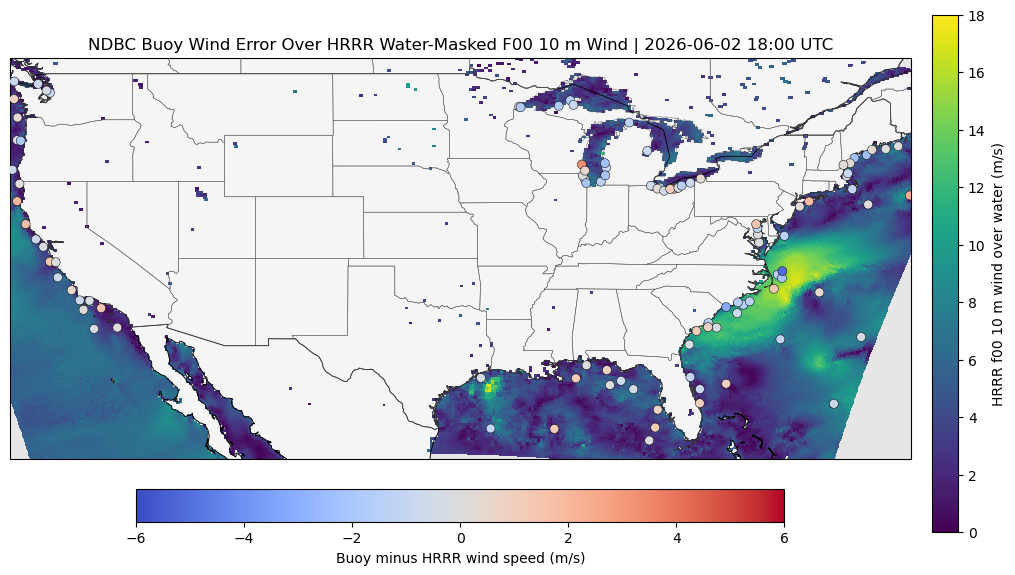

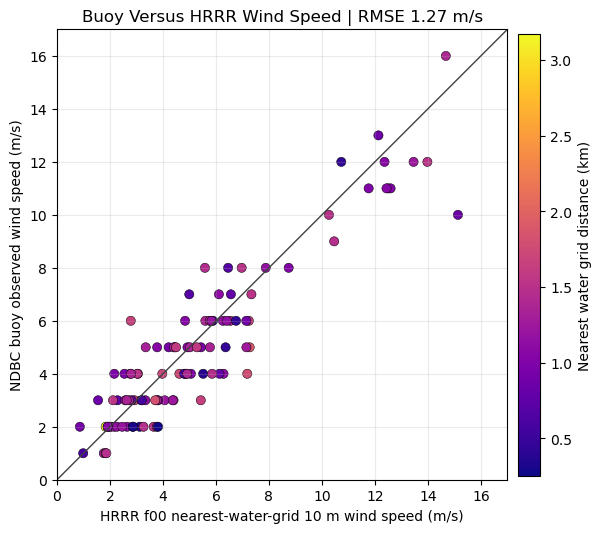

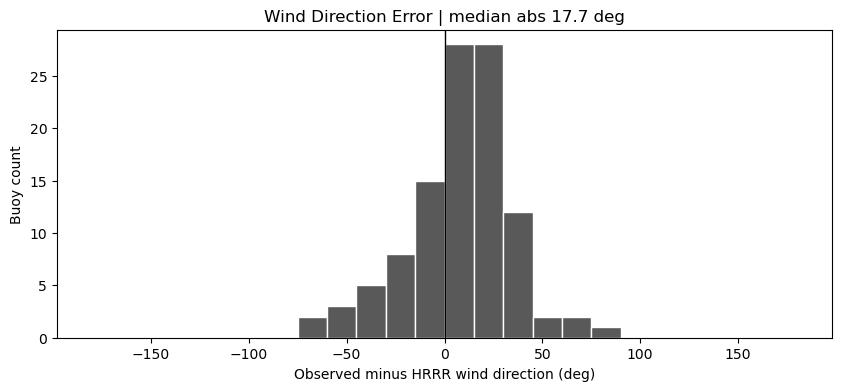

In [6]:
def add_map_features(ax):
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, facecolor="0.90", zorder=0)
    ax.add_feature(cfeature.LAKES, facecolor="0.90", edgecolor="0.55", linewidth=0.3, zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="0.96", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, zorder=3)
    ax.add_feature(cfeature.STATES, linewidth=0.35, edgecolor="0.35", zorder=3)


valid_label = pd.Timestamp(valid_time_utc).strftime("%Y-%m-%d %H:%M UTC")
hrrr_plot = hrrr_wind.isel(
    y=slice(None, None, hrrr_plot_stride),
    x=slice(None, None, hrrr_plot_stride),
)
hrrr_water_speed = hrrr_plot["wind_speed_mps"].where(hrrr_plot["water_mask"])

fig = plt.figure(figsize=(14, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
add_map_features(ax)
mesh = ax.pcolormesh(
    hrrr_plot["longitude"],
    hrrr_plot["latitude"],
    hrrr_water_speed,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=max(18, np.nanpercentile(hrrr_water_speed, 98)),
    zorder=1,
)
speed_cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, shrink=0.84)
speed_cbar.set_label("HRRR f00 10 m wind over water (m/s)")

error_norm = TwoSlopeNorm(vmin=-error_color_limit_mps, vcenter=0.0, vmax=error_color_limit_mps)
points = ax.scatter(
    matched["lon"],
    matched["lat"],
    c=matched["obs_minus_hrrr_speed_mps"],
    s=42,
    cmap="coolwarm",
    norm=error_norm,
    edgecolor="black",
    linewidth=0.35,
    transform=ccrs.PlateCarree(),
    zorder=4,
)
error_cbar = plt.colorbar(points, ax=ax, orientation="horizontal", pad=0.05, shrink=0.72)
error_cbar.set_label("Buoy minus HRRR wind speed (m/s)")
ax.set_title(f"NDBC Buoy Wind Error Over HRRR Water-Masked F00 10 m Wind | {valid_label}")
plt.show()


fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    matched["hrrr_wind_speed_mps"],
    matched["observed_wind_speed_mps"],
    c=matched["nearest_water_grid_distance_km"],
    cmap="plasma",
    s=44,
    edgecolor="black",
    linewidth=0.35,
)
limit = float(np.nanmax([matched["hrrr_wind_speed_mps"].max(), matched["observed_wind_speed_mps"].max()]))
limit = max(5.0, np.ceil(limit + 1.0))
ax.plot([0, limit], [0, limit], color="0.25", linewidth=1.0)
ax.set_xlim(0, limit)
ax.set_ylim(0, limit)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=0.25)
ax.set_xlabel("HRRR f00 nearest-water-grid 10 m wind speed (m/s)")
ax.set_ylabel("NDBC buoy observed wind speed (m/s)")
ax.set_title(f"Buoy Versus HRRR Wind Speed | RMSE {rmse_mps:.2f} m/s")
distance_cbar = plt.colorbar(ax.collections[0], ax=ax, pad=0.02, shrink=0.82)
distance_cbar.set_label("Nearest water grid distance (km)")
plt.show()


fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(matched["direction_error_deg"], bins=np.arange(-180, 181, 15), color="0.35", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Observed minus HRRR wind direction (deg)")
ax.set_ylabel("Buoy count")
ax.set_title(f"Wind Direction Error | median abs {direction_abs_error.median():.1f} deg")
plt.show()